## Yellow-legged hornet model

11 - Patch construction

12 - Grid Search

13 - PSO

14 - Simulation

**15 - Map**

**Spatial Division 1**

 Region 1: France

 Region 2: others

Spatial Division 2

 Region 1: France _+ Portugal

 Region 2: others


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import pyogrio

import os
import matplotlib as mpl

Mounted at /content/drive


In [ ]:
gpkg = ("/content/drive/MyDrive/MSC_PROJECT_YJ/outputs/"
    "hornet_plot_layers_FRonly.gpkg"
)


print(pyogrio.list_layers(gpkg))

[['patches' 'Polygon']
 ['land' 'Polygon']
 ['water' 'MultiPolygon']
 ['countries' 'MultiPolygon']
 ['study_area' 'Polygon']]


In [ ]:
patches = gpd.read_file(
    gpkg,
    layer="patches"
)

print(patches.columns.tolist())
print(patches.head())

['patch_id', 'cell_area', 'land_area', 'land_prop', 'occyear1', 'occyear2', 'land_centroid', 'A_i', 'region', 'geometry']
   patch_id    cell_area     land_area  land_prop  occyear1  occyear2  \
0         0  400000000.0  1.796594e+08   0.449148         0         0   
1         1  400000000.0  3.588828e+08   0.897207         0         0   
2         2  400000000.0  2.328088e+08   0.582022         1         1   
3         3  400000000.0  2.426348e+08   0.606587         1         1   
4         4  400000000.0  1.125199e+08   0.281300         1         1   

                           land_centroid         A_i  region  \
0  POINT (2755966.134143 2156580.001893)  179.659369       2   
1  POINT (2751923.621122 2137986.612305)  358.882792       2   
2  POINT (2774165.538482 2416511.727893)  232.808759       2   
3  POINT (2773988.511772 2400306.671631)  242.634810       2   
4  POINT (2776348.142842 2379904.065578)  112.519858       2   

                                            geometry  

In [ ]:
patches = gpd.read_file(gpkg, layer="patches")
land = gpd.read_file(gpkg, layer="land")
water = gpd.read_file(gpkg, layer="water")
countries = gpd.read_file(gpkg, layer="countries")
study_area = gpd.read_file(gpkg, layer="study_area")

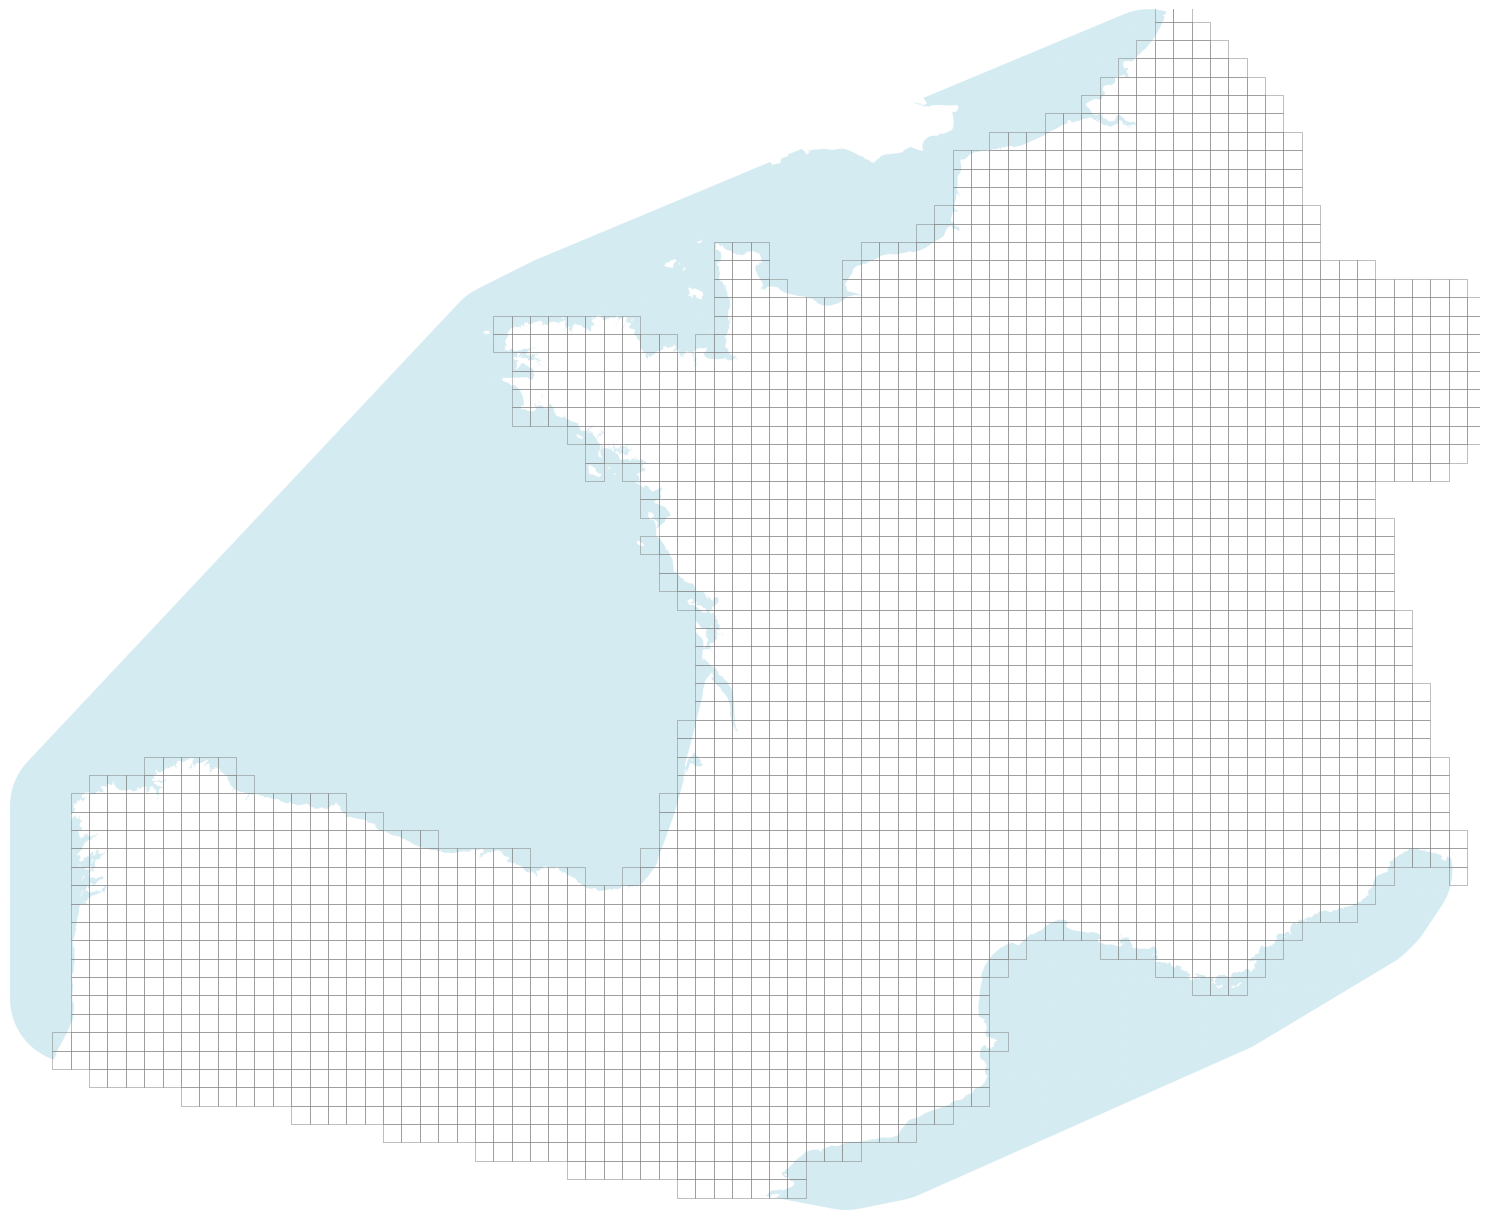

In [ ]:
fig, ax = plt.subplots(figsize=(15,15))

water.plot(
    ax=ax,
    facecolor="lightblue",
    edgecolor="none",
    alpha=0.5,
    zorder=1
)

land.plot(
    ax=ax,
    facecolor="white",
    edgecolor="none",
    alpha=0.5,
    zorder=2
)

patches.boundary.plot(
    ax=ax,
    color="grey",
    alpha=0.6,
    linewidth=0.6,
    zorder=3
)

# countries.boundary.plot(
#     ax=ax,
#     color="black",
#     linewidth=0.6,
#     alpha=0.5,
#     zorder=4
# )

xmin, ymin, xmax, ymax = study_area.total_bounds
ax.set_xlim(xmin, xmax)
ax.set_ylim(ymin, ymax)

ax.set_aspect("equal")
ax.set_axis_off()

plt.tight_layout()
plt.show()

In [ ]:
patch_results_d1_gs_deter = pd.read_csv(
    "/content/drive/MyDrive/MSC_PROJECT_YJ/outputs/"
    "hornet_patch_results_d1_gs_deter.csv"
)

map_d1_gs = patches.merge(
    patch_results_d1_gs_deter,
    on="patch_id",
    how="left",
    validate="one_to_many"
)

print(map_d1_gs.shape)
print(map_d1_gs["year"].unique())

(51340, 17)
[2020 2030 2040 2050 2060 2070 2080 2090 2100 2110 2120 2130 2140 2150
 2160 2170 2180 2190 2200 2210]


In [ ]:
# regional boundaries

region_boundaries = (
    patches[
        patches["region"].isin([1, 2])
    ]
    .dissolve(by="region")
)

region_boundaries

,geometry,patch_id,cell_area,land_area,land_prop,occyear1,occyear2,land_centroid,A_i
region,,,,,,,,,
1,"POLYGON ((3360998.39 2328583.113, 3360998.39 2...",401,400000000.0,1.749948e+07,0.043749,0,0,POINT (3239323.77218 2930960.061195),17.499480
2,"MULTIPOLYGON (((2760998.39 2188583.113, 276099...",0,400000000.0,1.796594e+08,0.449148,0,0,POINT (2755966.134143 2156580.001893),179.659369


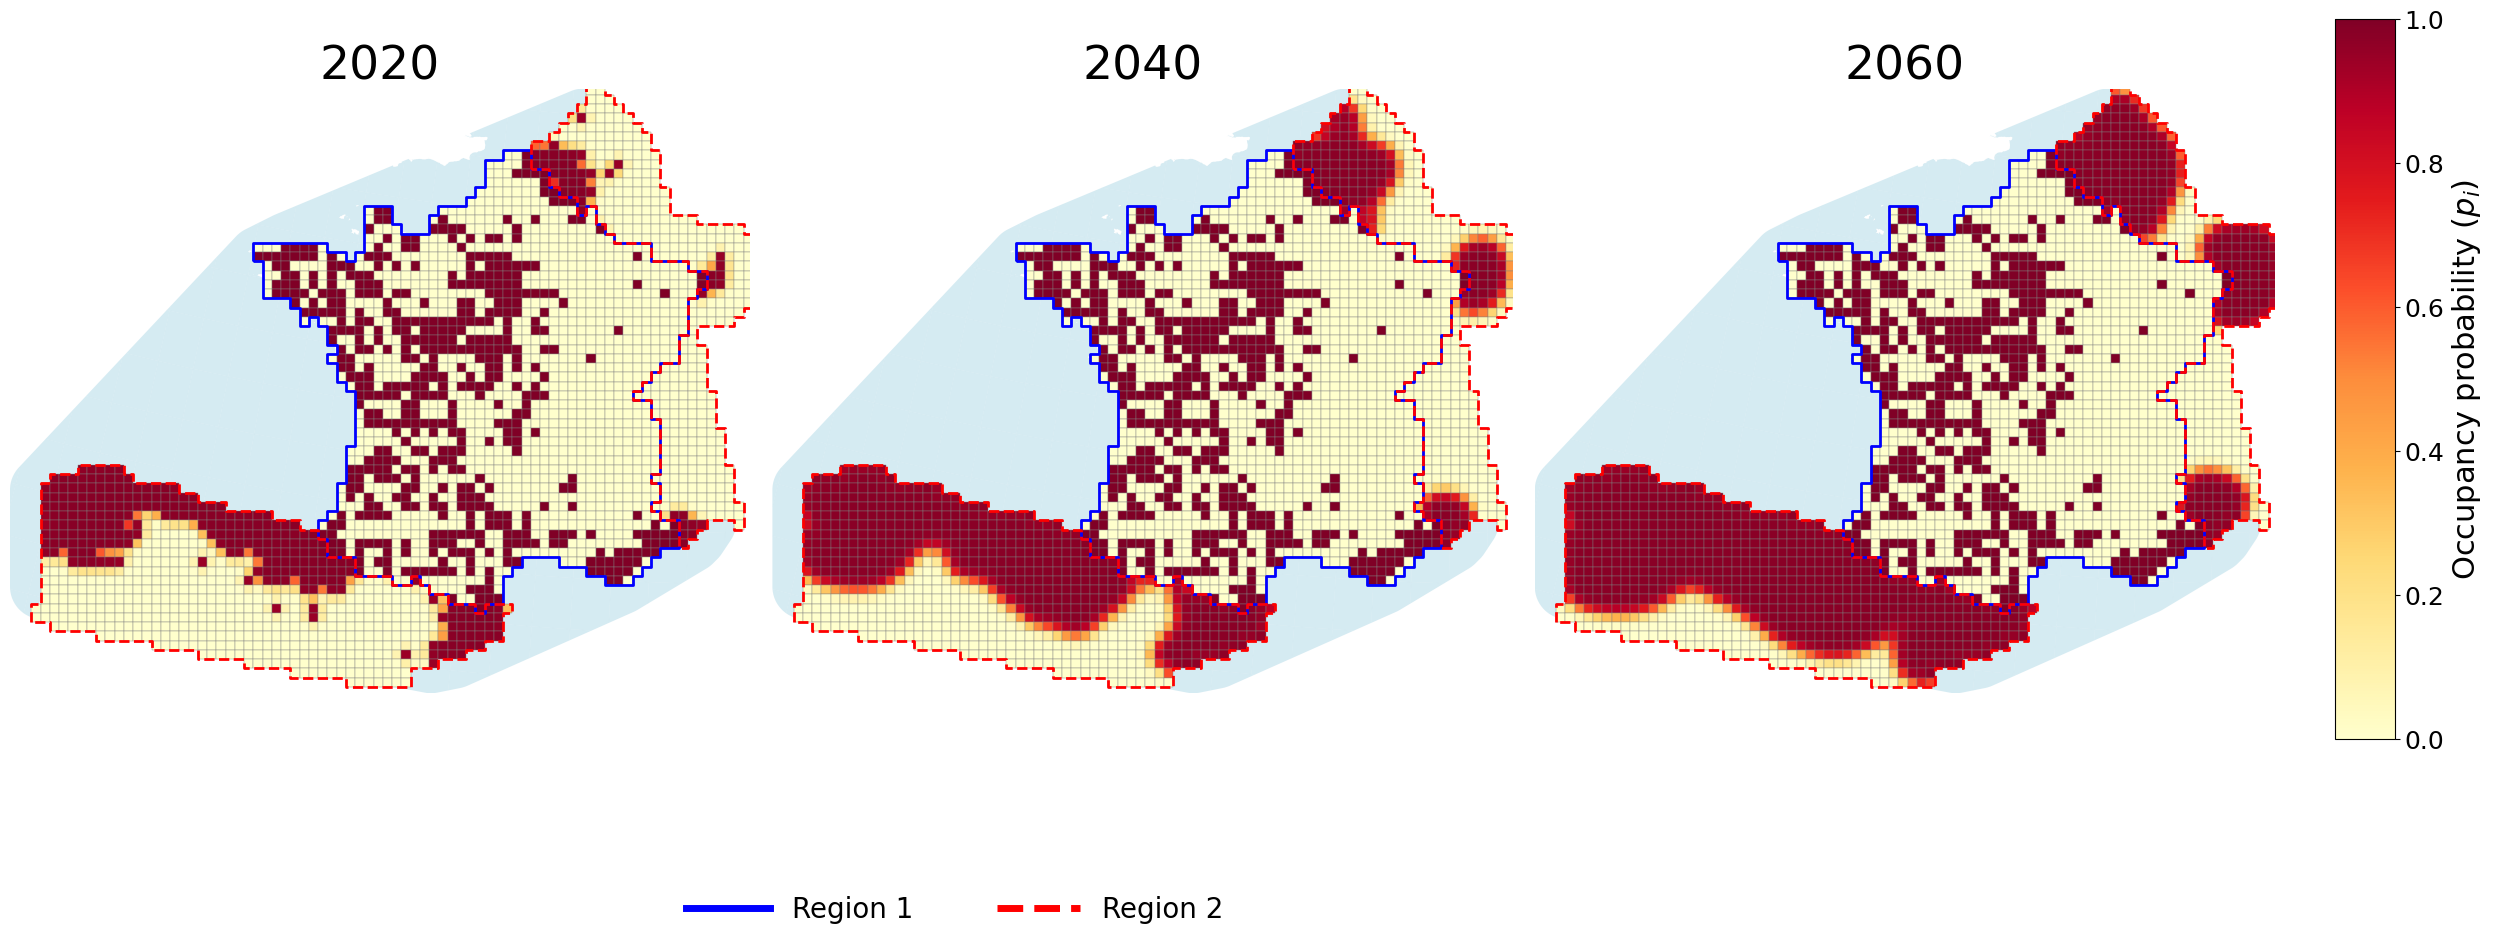

In [ ]:
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.lines import Line2D

years = [2020, 2040, 2060]


region_boundaries = (
    patches[
        patches["region"].isin([1, 2])
    ]
    .dissolve(by="region")
)

fig, axes = plt.subplots(
    1, 3,
    figsize=(30, 12)
)

axes = axes.flatten()


xmin, ymin, xmax, ymax = study_area.total_bounds

norm = mpl.colors.Normalize(vmin=0, vmax=1)
cmap = "YlOrRd"

for ax, year in zip(axes, years):

    map_year = map_d1_gs[
        map_d1_gs["year"] == year
    ].copy()


    water.plot(
        ax=ax,
        facecolor="lightblue",
        edgecolor="none",
        alpha=0.5,
        zorder=1
    )


    land.plot(
        ax=ax,
        facecolor="white",
        edgecolor="none",
        alpha=0.5,
        zorder=2
    )

    map_year.plot(
        ax=ax,
        column="p_next",
        cmap=cmap,
        norm=norm,
        edgecolor="grey",
        linewidth=0.3,
        zorder=3
    )


    region_boundaries.loc[[1]].boundary.plot(
        ax=ax,
        color="blue",
        linewidth=2,
        zorder=4
    )


    region_boundaries.loc[[2]].boundary.plot(
        ax=ax,
        color="red",
        linewidth=2,
        linestyle="--",
        zorder=4
    )

    ax.set_xlim(xmin, xmax)
    ax.set_ylim(ymin, ymax)
    ax.set_aspect("equal")
    ax.set_axis_off()

    ax.set_title(
        str(year),
        fontsize=34
    )


fig.subplots_adjust(
    right=0.88,
    bottom=0.10,
    wspace=0.03,
    hspace=0.03
)

# shared colour bar
sm = mpl.cm.ScalarMappable(
    norm=norm,
    cmap=cmap
)

sm.set_array([])

cax = fig.add_axes([
    0.90,
    0.20,
    0.02,
    0.60
])

cbar = fig.colorbar(
    sm,
    cax=cax
)

cbar.set_label(
    r"Occupancy probability ($p_i$)",
    fontsize=22
)

cbar.ax.tick_params(
    labelsize=18
)

# Region legend
region_legend = [
    Line2D(
        [0], [0],
        color="blue",
        linewidth=5,
        label="Region 1"
    ),

    Line2D(
        [0], [0],
        color="red",
        linewidth=5,
        linestyle="--",
        label="Region 2"
    )
]

fig.legend(
    handles=region_legend,
    loc="lower center",
    bbox_to_anchor=(0.44, 0.025),
    ncol=2,
    prop={"size": 20},
    handlelength=3,
    columnspacing=3,
    frameon=False
)

plt.show()

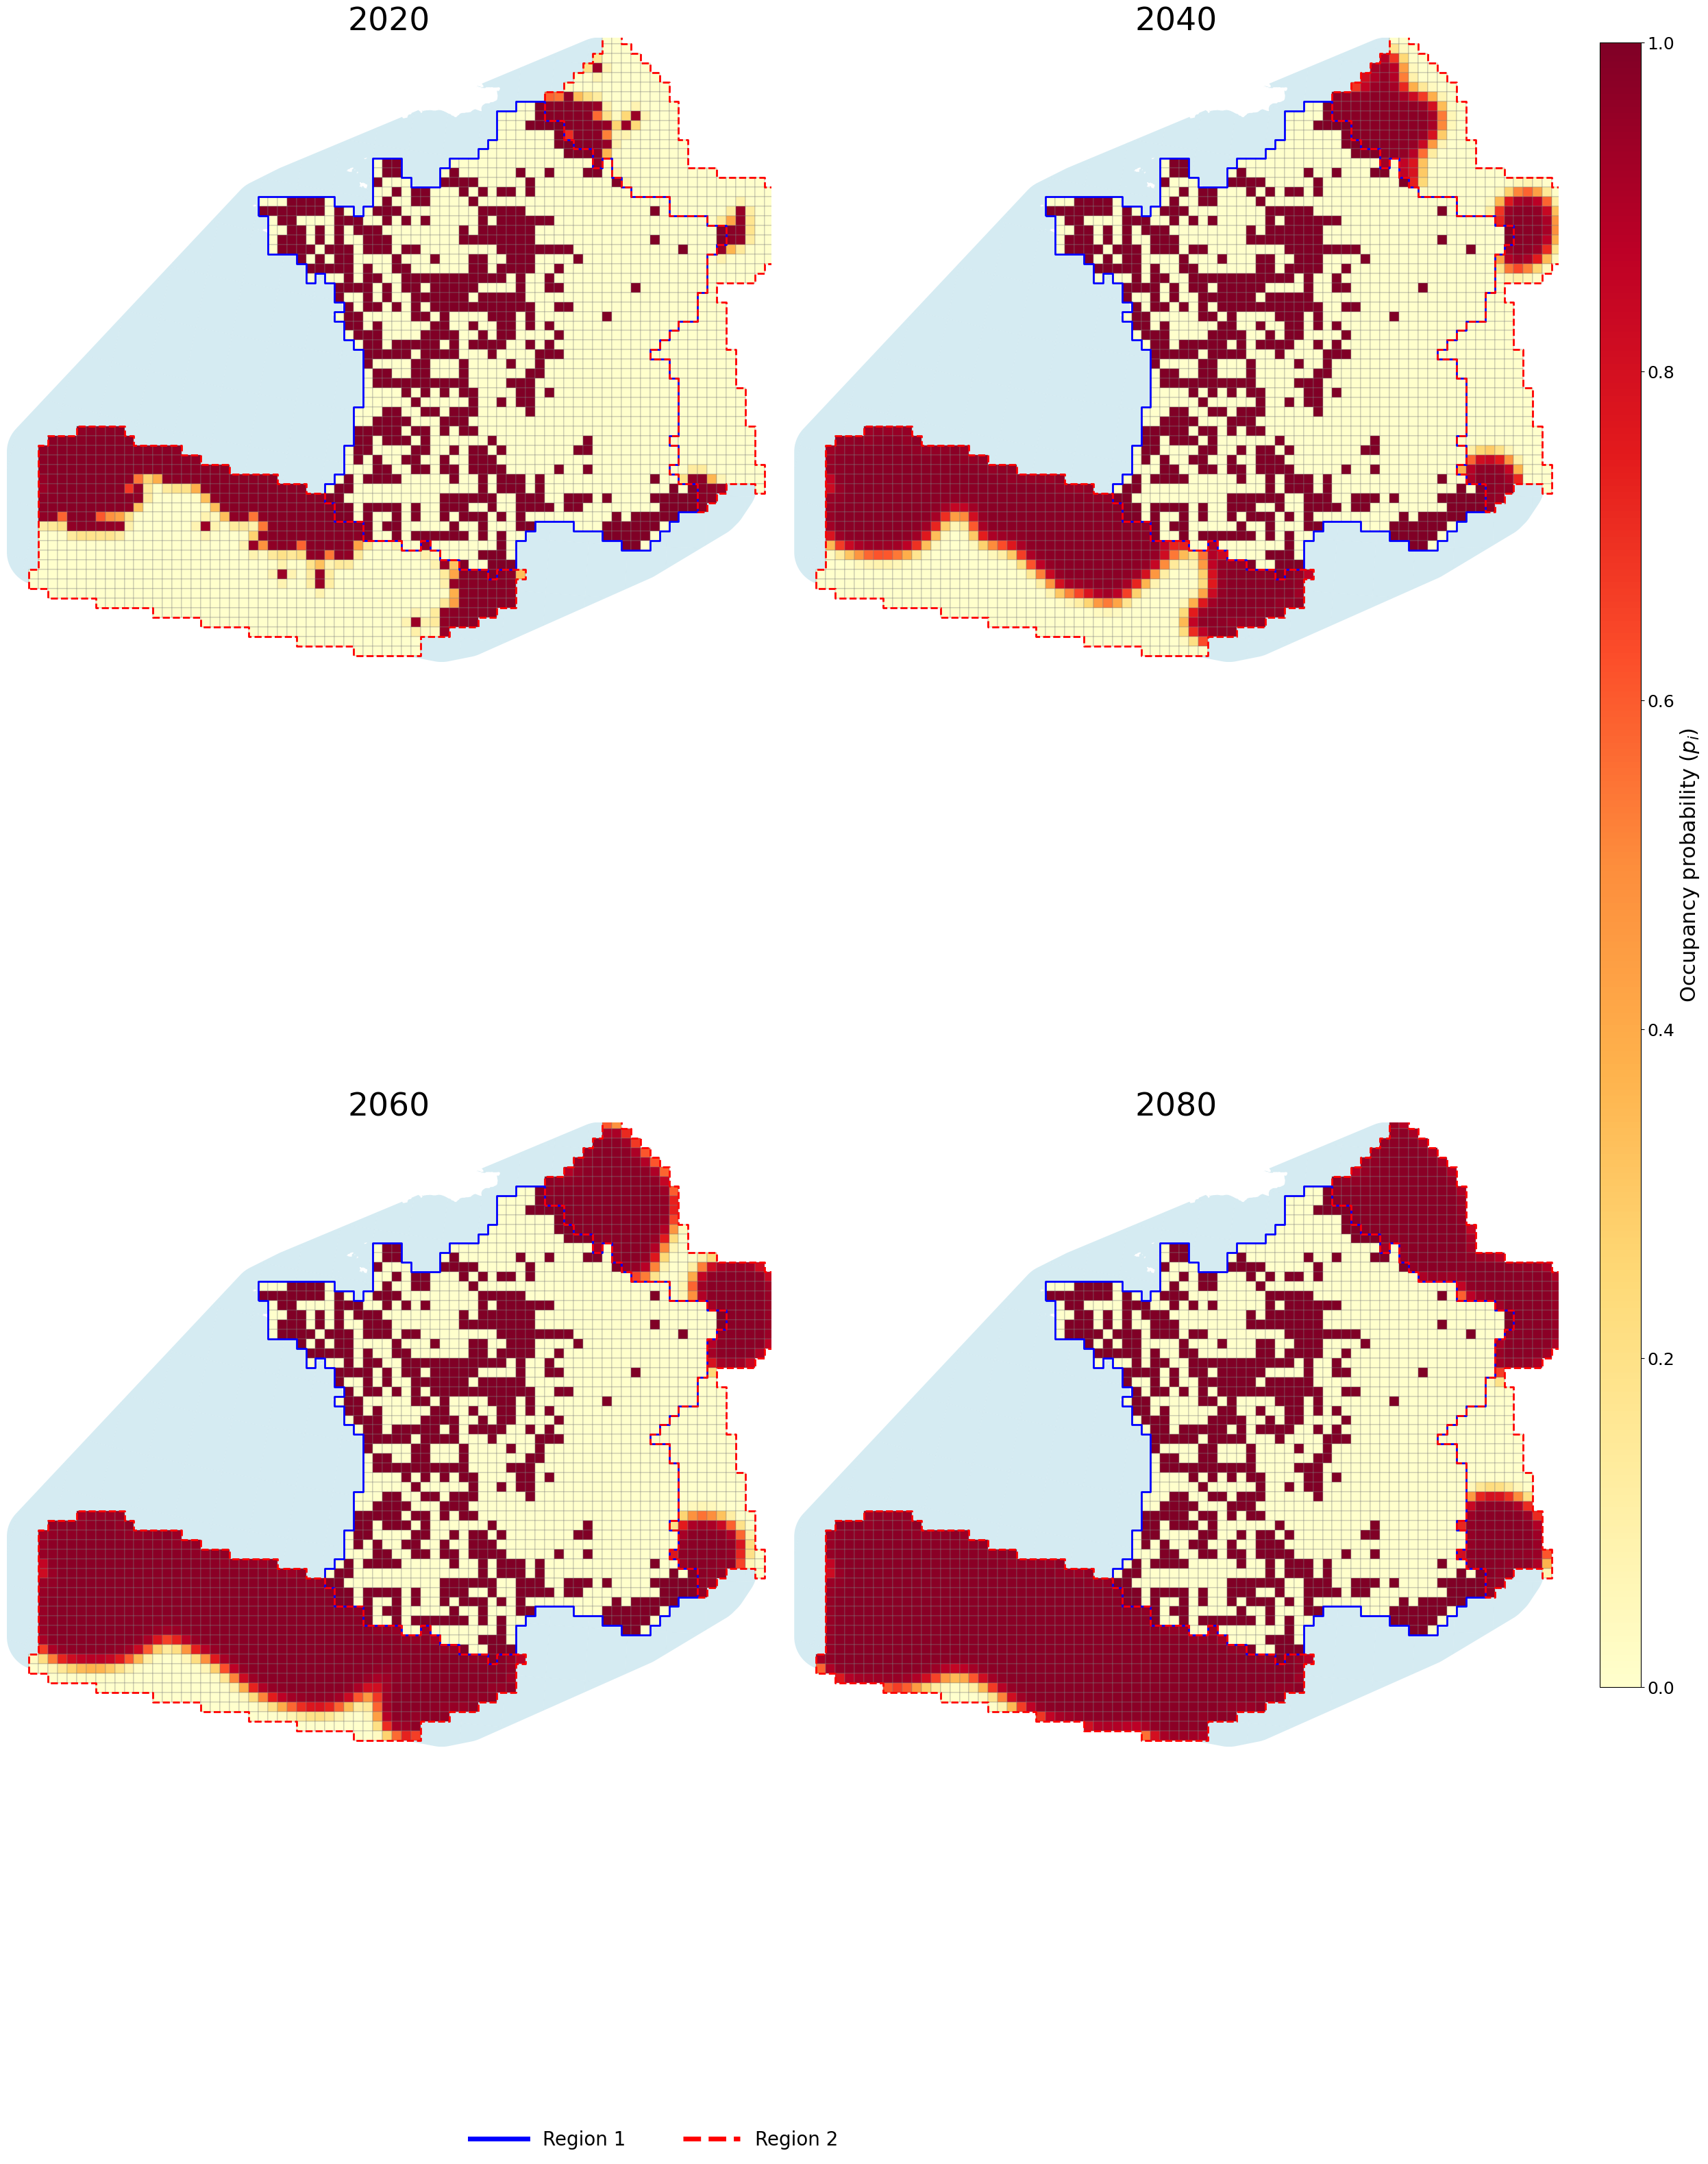

In [ ]:
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.lines import Line2D

years = [2020, 2040, 2060, 2080]


region_boundaries = (
    patches[
        patches["region"].isin([1, 2])
    ]
    .dissolve(by="region")
)

fig, axes = plt.subplots(
    2,2,
    figsize=(30, 40)

)


axes = axes.flatten()


xmin, ymin, xmax, ymax = study_area.total_bounds

norm = mpl.colors.Normalize(vmin=0, vmax=1)
cmap = "YlOrRd"

for ax, year in zip(axes, years):

    map_year = map_d1_gs[
        map_d1_gs["year"] == year
    ].copy()


    water.plot(
        ax=ax,
        facecolor="lightblue",
        edgecolor="none",
        alpha=0.5,
        zorder=1
    )


    land.plot(
        ax=ax,
        facecolor="white",
        edgecolor="none",
        alpha=0.5,
        zorder=2
    )


    map_year.plot(
        ax=ax,
        column="p_next",
        cmap=cmap,
        norm=norm,
        edgecolor="grey",
        linewidth=0.3,
        zorder=3
    )


    region_boundaries.loc[[1]].boundary.plot(
        ax=ax,
        color="blue",
        linewidth=2,
        zorder=4
    )

  
    region_boundaries.loc[[2]].boundary.plot(
        ax=ax,
        color="red",
        linewidth=2,
        linestyle="--",
        zorder=4
    )

    ax.set_xlim(xmin, xmax)
    ax.set_ylim(ymin, ymax)
    ax.set_aspect("equal")
    ax.set_axis_off()

    ax.set_title(
        str(year),
        fontsize=34
    )


fig.subplots_adjust(
    right=0.88,
    bottom=0.10,
    wspace=0.03,
    hspace=0.03
)


sm = mpl.cm.ScalarMappable(
    norm=norm,
    cmap=cmap
)

sm.set_array([])

cax = fig.add_axes([
    0.90,
    0.20,
    0.02,
    0.60
])

cbar = fig.colorbar(
    sm,
    cax=cax
)

cbar.set_label(
    r"Occupancy probability ($p_i$)",
    fontsize=22
)

cbar.ax.tick_params(
    labelsize=18
)

region_legend = [
    Line2D(
        [0], [0],
        color="blue",
        linewidth=5,
        label="Region 1"
    ),

    Line2D(
        [0], [0],
        color="red",
        linewidth=5,
        linestyle="--",
        label="Region 2"
    )
]

fig.legend(
    handles=region_legend,
    loc="lower center",
    bbox_to_anchor=(0.44, 0.025),
    ncol=2,
    prop={"size": 20},
    handlelength=3,
    columnspacing=3,
    frameon=False
)

plt.show()

In [ ]:
from matplotlib.animation import FuncAnimation, PillowWriter
from IPython.display import HTML, display
import matplotlib.pyplot as plt
import matplotlib as mpl

years = [
    year for year in sorted(map_d1_gs["year"].unique())
    if 2020 <= year <= 2210 and (year - 2020) % 10 == 0
]

xmin, ymin, xmax, ymax = study_area.total_bounds

norm = mpl.colors.Normalize(vmin=0, vmax=1)
cmap = "YlOrRd"

fig, ax = plt.subplots(figsize=(10, 10))

sm = mpl.cm.ScalarMappable(
    norm=norm,
    cmap=cmap
)
sm.set_array([])

cbar = fig.colorbar(
    sm,
    ax=ax,
    fraction=0.035,
    pad=0.02
)

cbar.set_label(
    r"Occupancy probability ($p_i$)",
    fontsize=22
)
cbar.ax.tick_params(labelsize=18)

def update(year):
    ax.clear()

    map_year = map_d1_gs[
        map_d1_gs["year"] == year
    ]

    water.plot(
        ax=ax,
        facecolor="lightblue",
        edgecolor="none",
        alpha=0.5,
        zorder=1
    )

    land.plot(
        ax=ax,
        facecolor="white",
        edgecolor="none",
        alpha=0.5,
        zorder=2
    )

    map_year.plot(
        ax=ax,
        column="p_next",
        cmap=cmap,
        norm=norm,
        edgecolor="grey",
        linewidth=0.25,
        zorder=3
    )

    countries.boundary.plot(
        ax=ax,
        color="black",
        linewidth=0.4,
        alpha=0.5,
        zorder=4
    )

    ax.set_xlim(xmin, xmax)
    ax.set_ylim(ymin, ymax)
    ax.set_aspect("equal")
    ax.set_axis_off()

    ax.set_title(
        f"{int(year)}",
        fontsize=22
    )

animation = FuncAnimation(
    fig,
    update,
    frames=years,
    interval=500,
    repeat=True
)

display(HTML(animation.to_jshtml()))

gif_path = (
    "/content/drive/MyDrive/MSC_PROJECT_YJ/outputs/"
    "hornet_GS_projection_deter_0902.gif"
)

animation.save(
    gif_path,
    writer=PillowWriter(fps=1.25),
    dpi=120
)

plt.close(fig)

Output hidden; open in https://colab.research.google.com to view.

# R1 parameters only

In [ ]:
patch_results_d1_gs_r1_only_deter = pd.read_csv(
    "/content/drive/MyDrive/MSC_PROJECT_YJ/outputs/"
    "hornet_patch_results_d1_gs_r1_only_deter.csv"
)

map_d1_gs_r1_only = patches.merge(
    patch_results_d1_gs_r1_only_deter,
    on="patch_id",
    how="left",
    validate="one_to_many"
)

print(patch_results_d1_gs_r1_only_deter.shape)
print(patch_results_d1_gs_r1_only_deter.columns)
print(patch_results_d1_gs_r1_only_deter["year"].unique())
print(map_d1_gs_r1_only.shape)
print(map_d1_gs_r1_only["year"].unique())

(51340, 8)
Index(['step', 'year', 'patch_id', 'region', 'E_i', 'S_i', 'C_i', 'p_next'], dtype='object')
[2020 2030 2040 2050 2060 2070 2080 2090 2100 2110 2120 2130 2140 2150
 2160 2170 2180 2190 2200 2210]
(51340, 17)
[2020 2030 2040 2050 2060 2070 2080 2090 2100 2110 2120 2130 2140 2150
 2160 2170 2180 2190 2200 2210]


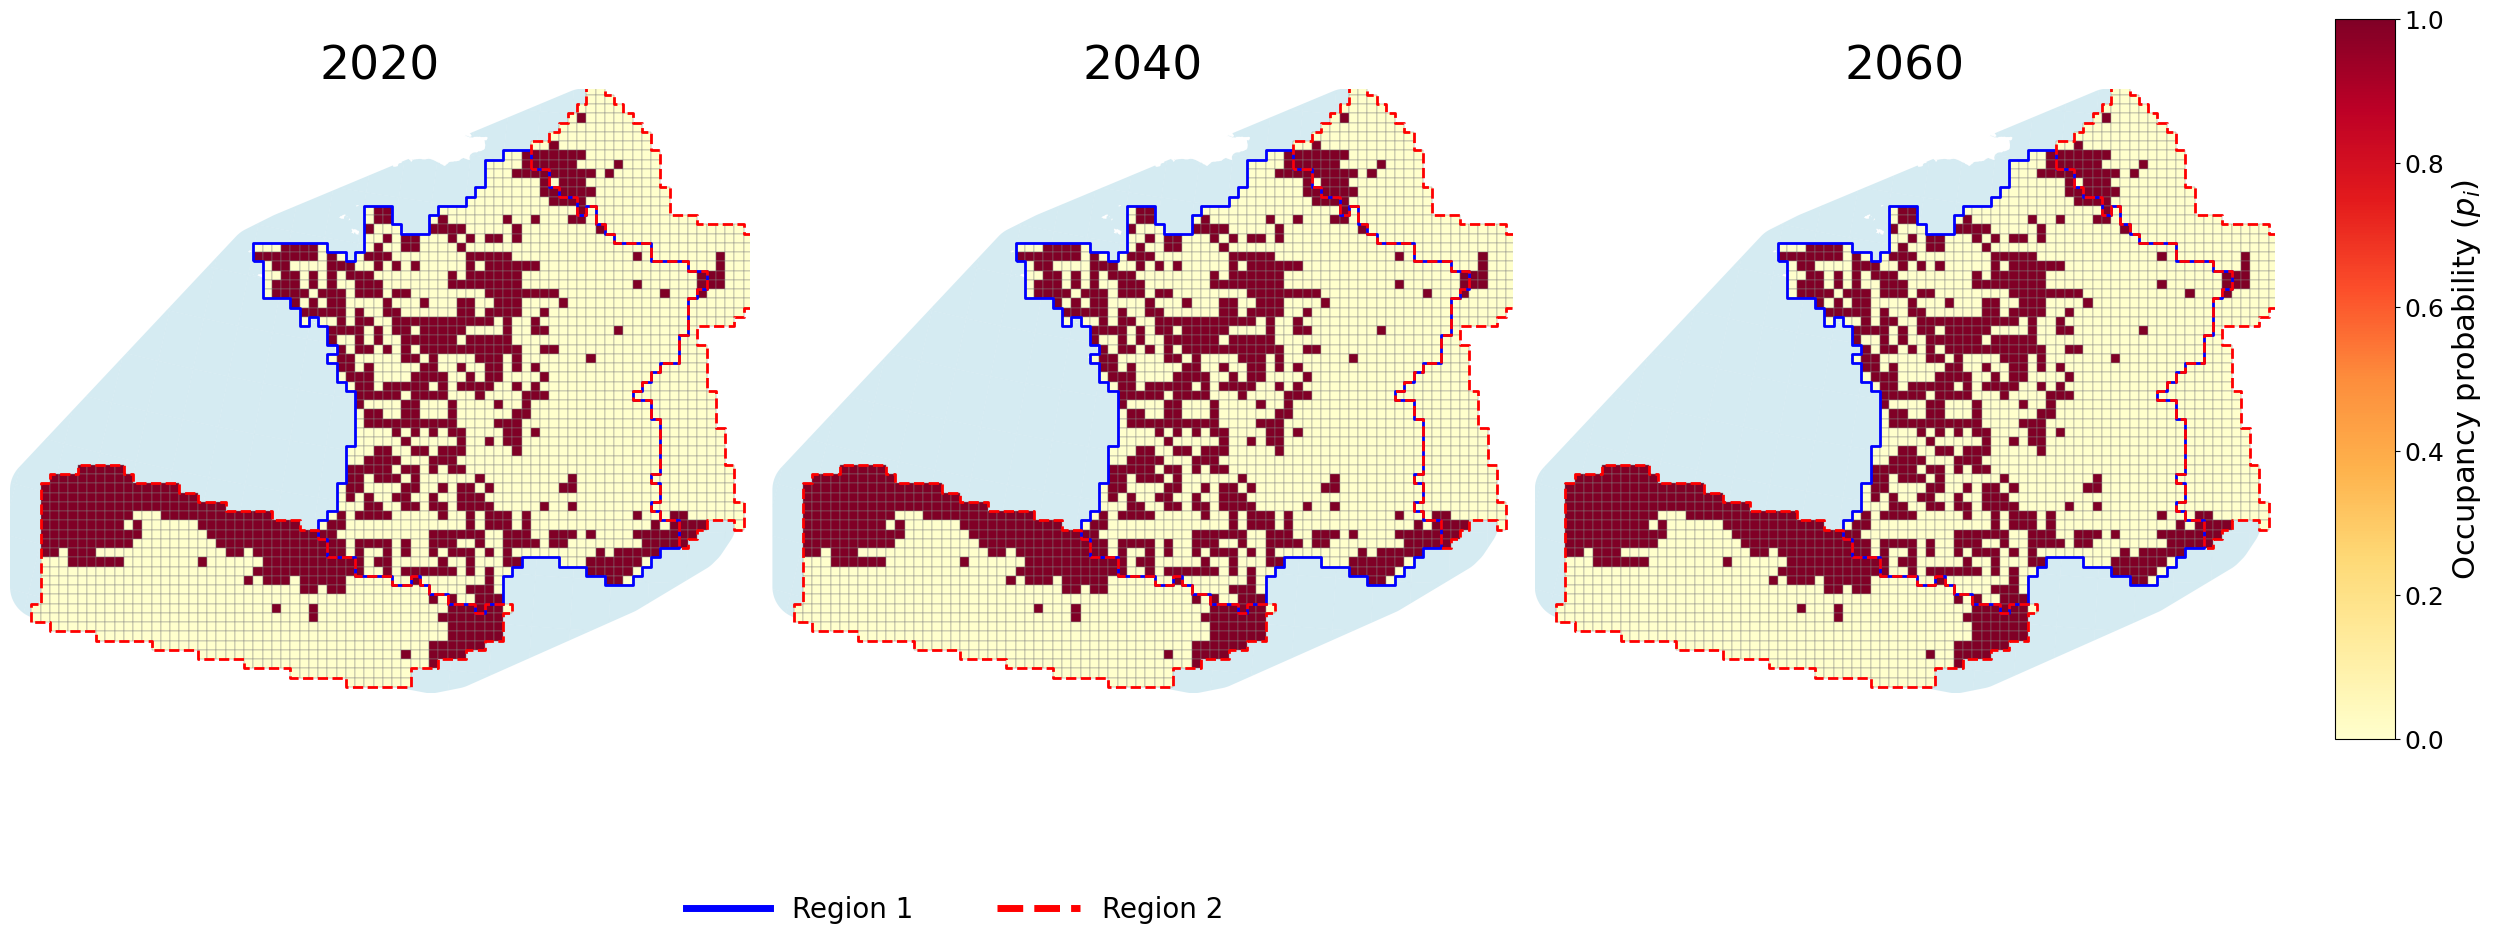

In [ ]:
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.lines import Line2D

years = [2020, 2040, 2060]

# Region boundaries
region_boundaries = (
    patches[
        patches["region"].isin([1, 2])
    ]
    .dissolve(by="region")
)

fig, axes = plt.subplots(
    1, 3,
    figsize=(30, 12)
)

axes = axes.flatten()

xmin, ymin, xmax, ymax = study_area.total_bounds
norm = mpl.colors.Normalize(vmin=0, vmax=1)
cmap = "YlOrRd"

for ax, year in zip(axes, years):

    map_year = map_d1_gs_r1_only[
        map_d1_gs_r1_only["year"] == year
    ].copy()


    water.plot(
        ax=ax,
        facecolor="lightblue",
        edgecolor="none",
        alpha=0.5,
        zorder=1
    )


    land.plot(
        ax=ax,
        facecolor="white",
        edgecolor="none",
        alpha=0.5,
        zorder=2
    )

    map_year.plot(
        ax=ax,
        column="p_next",
        cmap=cmap,
        norm=norm,
        edgecolor="grey",
        linewidth=0.3,
        zorder=3
    )


    region_boundaries.loc[[1]].boundary.plot(
        ax=ax,
        color="blue",
        linewidth=2,
        zorder=4
    )


    region_boundaries.loc[[2]].boundary.plot(
        ax=ax,
        color="red",
        linewidth=2,
        linestyle="--",
        zorder=4
    )

    ax.set_xlim(xmin, xmax)
    ax.set_ylim(ymin, ymax)
    ax.set_aspect("equal")
    ax.set_axis_off()

    ax.set_title(
        str(year),
        fontsize=34
    )

fig.subplots_adjust(
    right=0.88,
    bottom=0.10,
    wspace=0.03,
    hspace=0.03
)


sm = mpl.cm.ScalarMappable(
    norm=norm,
    cmap=cmap
)
sm.set_array([])

cax = fig.add_axes([
    0.90,
    0.20,
    0.02,
    0.60
])

cbar = fig.colorbar(
    sm,
    cax=cax
)

cbar.set_label(
    r"Occupancy probability ($p_i$)",
    fontsize=22
)

cbar.ax.tick_params(
    labelsize=18
)

region_legend = [
    Line2D(
        [0], [0],
        color="blue",
        linewidth=5,
        label="Region 1"
    ),
    Line2D(
        [0], [0],
        color="red",
        linewidth=5,
        linestyle="--",
        label="Region 2"
    )
]

fig.legend(
    handles=region_legend,
    loc="lower center",
    bbox_to_anchor=(0.44, 0.025),
    ncol=2,
    prop={"size": 20},
    handlelength=3,
    columnspacing=3,
    frameon=False
)

plt.show()